# Sare Neuronalak PyTorch erabiliz 🧠

## Sarrera

Sare Neuronalak giza garunaren funtzionamenduan inspiratutako algoritmoak dira. Ezagutzen dituzuen algoritmoek ez bezala (KNN, Decision Trees, Naive Bayes), sare neuronalek datuen irudikapen konplexuagoak ikas ditzakete transformazio ez-linealen geruzen bidez.


### Zer da jada dakiguna?

- **KNN**: Distantzietan oinarritua, entrenatu beharreko parametrorik gabe
- **Decision Trees**: Arau sinpleak sortzen ditu, interpretagarria da
- **Naive Bayes**: Suposizioetan oinarritutako probabilitate-eredua
- **Sare Neuronalak**: Milaka/milioi parametro ikasi iterazio-optimizazioaren bidez


In [3]:
## importak
###########
## pytorch
import torch
import torch.nn as nn
import torch.optim as optim

## sklearn, numpy, mpl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# grafikoen aurrekonfigurazioa
plt.style.use('seaborn-v0_8-whitegrid')

## CUDA?
print(f"PyTorch bertsioa: {torch.__version__}")
print(f"GPU erabilgai?: {torch.cuda.is_available()}")

# seed-ak ezarri
np.random.seed(42)
torch.manual_seed(42)

PyTorch bertsioa: 2.10.0+cpu
GPU erabilgai?: False


## 1️⃣ Sare Neuronalen Oinarriak

### Oinarrizko Arkitektura

Sare Neuronal Sakon batek hiru geruza desberdin ditu;

1. **Sarrera (Input Layer)**: Datuak jasotzen ditu
2. **Ezkutuak (Hidden Layers)**: Datuak prozesatu eta transformatu
3. **Irteera (Output Layer)**: Iragarpenak kalkulatzen ditu

sare_neuronala_eskema.svg

### Elementu Nagusiak: Pisuak (Weights) eta biasak (Biases)

- **Pisuak (W)**: Sareak entrenamenduan ikasten dituen parametroak
- **Bias (b)**: Modeloari malgutasuna eransten dioten desplazamendu-terminoak

Neurona bakotzak: $irteera = \sigma(W \cdot sarrera + b)$

## 2️⃣ Neuronak eta Aktibazio funtzioak ($\sigma$)

### Zergatik dira beharrezkoak aktibazio funtzioak?

Aktibazio-funtziorik gabe, sare neuronal bat batuketak eta biderketak baino ez lirateke izango (transformazio linealak). Aktibazio-funtzioek **linealtasun eza** gehitzen dute, eta sareak patroi konplexuak ikas ditzake.

### Aktibazio funtzio ohikoak

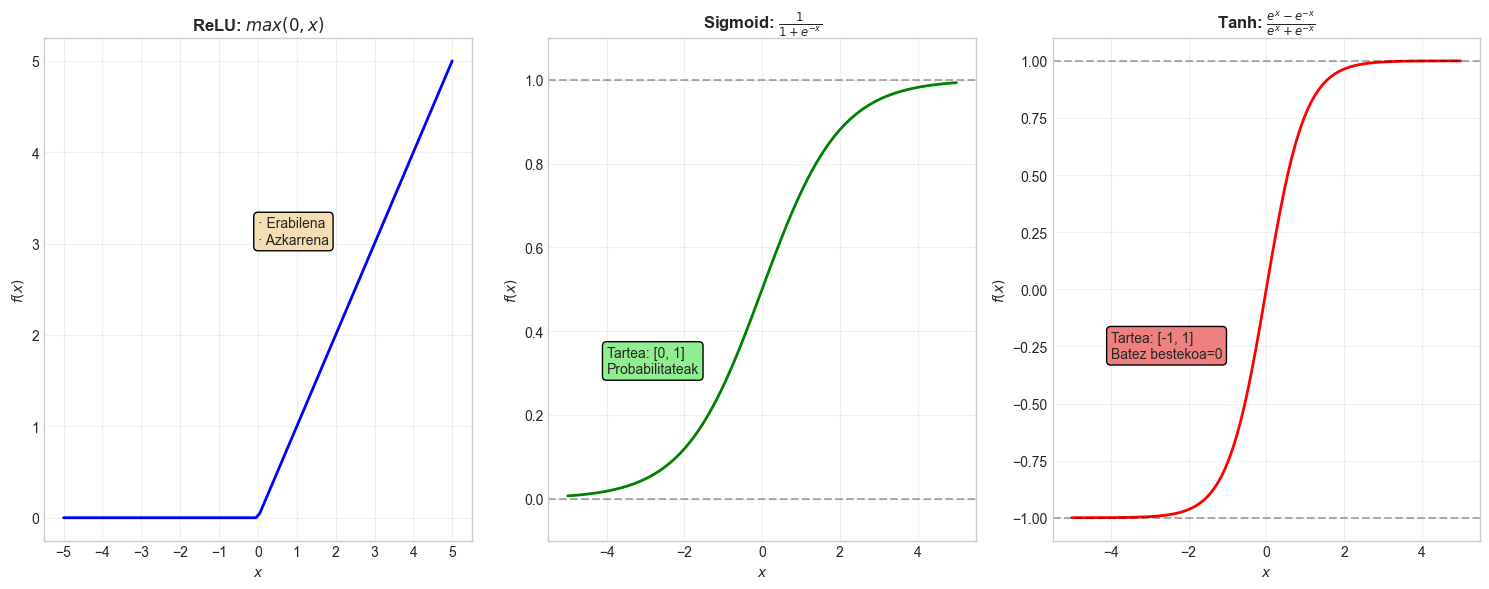

In [4]:
# irudikapena
x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# ReLU (Rectified Linear Unit)
relu = np.maximum(0, x)
axes[0].plot(x, relu, 'b-', linewidth=2)
axes[0].set_title(r'ReLU: $max(0, x)$', fontsize=12, fontweight='bold')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f(x)$')
axes[0].grid(True, alpha=0.3)
axes[0].text(0, 3, '· Erabilena\n· Azkarrena', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))
axes[0].set_xticks( list(range(-5,6)) )

# Sigmoid
sigmoid = 1 / (1 + np.exp(-x))
axes[1].plot(x, sigmoid, 'g-', linewidth=2)
axes[1].set_title(r'Sigmoid: $\frac{1}{1 + e^{-x}}$', fontsize=12, fontweight='bold')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$f(x)$')
axes[1].set_ylim([-0.1, 1.1])
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=1.0, linestyle='--', alpha=0.3,c='black')
axes[1].axhline(y=0.0, linestyle='--', alpha=0.3,c='black')
axes[1].text(-4, 0.3, 'Tartea: [0, 1]\nProbabilitateak', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen'))

# Tanh
tanh = np.tanh(x)
axes[2].plot(x, tanh, 'r-', linewidth=2)
axes[2].set_title(r'Tanh: $\frac{e^x - e^{-x}}{e^x + e^{-x}}$', fontsize=12, fontweight='bold')
axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$f(x)$')
axes[2].set_ylim([-1.1, 1.1])
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=1.0, linestyle='--', alpha=0.3,c='black')
axes[2].axhline(y=-1.0, linestyle='--', alpha=0.3,c='black')
axes[2].text(-4, -0.3, 'Tartea: [-1, 1]\nBatez bestekoa=0', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral'))

plt.tight_layout()
plt.show()

fig.savefig(
    fname='irudiak/aktibazio_funtzioak.pdf',
    format='pdf',
    bbox_inches="tight",
    pad_inches='layout'
)

**ReLU**
- Ezkutuko kapetan erabilia
- Gradientea desagertzeko arazoak konpontzen du

**Sigmoidea**
- Sailkapen bitarrean erabilia
- Irteerak probabilitateak bihurtu ditzake, 0tik 1erako delako.

**Tangente hiperbolikoa**
- Sigmoide bezala baina -1 etik 1 era.

## 3️⃣ Sare Neuronala PyTorch erabiliz

### Oinarrizko egitura: nn.Module -ren herentzia

PyTorch-en sare neuronal bat egiteko, klase bezala definitu behar da eta herentzia adierazteko `nn.Module` parentesi artean pasatu behar zaio. Hurrengo metodoak beharrezkoak dira definizio teknikorako:
1. `__init__`: Geruzak hasieratzeko
2. `forward`: Datuak nola prozesatuko diren adierazteko, adibidez, aktibazio funtzioa adierazi.

In [5]:
# Sare Neuronal sinplea
class SareNeuronalSinplea(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SareNeuronalSinplea, self).__init__()

        # geruzak definitzeko : nn.Linear
        self.geruza_izkutu_1 = nn.Linear(input_size, hidden_size)  # sarrera -> hidden layer 1
        self.irteera_geruza = nn.Linear(hidden_size, output_size)  # hidden layer 1 -> irteera

    def forward(self, x):
        # lehenengo geruza eta relu aplikatu
        x = self.geruza_izkutu_1(x)
        x = torch.relu(x)

        # geruza izkututik irteera geruzara
        x = self.irteera_geruza(x)

        return x

# SNren instantzia sortu
modelo = SareNeuronalSinplea(input_size=4, hidden_size=8, output_size=3)
print("Modeloa ondo sortu da!")
print("\nModelo egitura:")
print(modelo)

# Parametro deskribapena
total_params = sum(p.numel() for p in modelo.parameters())
print(f"\nGuztirako elementu: {total_params}") # (input_size + 1) * hidden_size + (hidden_size + 1) * output_size

# nodo kontaketa
total_nodes = sum(
    layer.out_features
    for _,layer in modelo.named_modules()
    if isinstance(layer, nn.Linear)
)
print(f'Sare neuronaleko nodoak: {total_nodes}')

Modeloa ondo sortu da!

Modelo egitura:
SareNeuronalSinplea(
  (geruza_izkutu_1): Linear(in_features=4, out_features=8, bias=True)
  (irteera_geruza): Linear(in_features=8, out_features=3, bias=True)
)

Guztirako elementu: 67
Sare neuronaleko nodoak: 11


## 4️⃣ Kapak ulertzen: nn.Linear

### Zer da nn.Linear?

`nn.Linear(in_features, out_features)`-k erabat konektatutako geruza bat sortzen du, hurrengoa betez:
- `in_features` parametroak, sarrera balioak hartzen ditu.
- `out_features` parametroak, irteera balioak hartzen ditu.

Parametroak guztira = `in_features * out_features` weight + `out_features` bias

### Adibide bat: Parametroak eskuz kalkulatzea

In [6]:
# Geruza bakoitzeko parametroak ikuskatu
print("=" * 60)
print("GERUZA EZAUGARRIAK")
print("=" * 60)

for nombre, capa in modelo.named_modules():
    if isinstance(capa, nn.Linear):
        print(f"Geruza izena: {nombre}")
        print(f"\tInput features: {capa.in_features}")
        print(f"\tOutput features: {capa.out_features}")
        print(f"\tWeight (W) shape: {capa.weight.shape}")  # out_features x in_features
        print(f"\tBias (b) shape: {capa.bias.shape}")    # bias

        # Parametroak kalkulatu
        num_pisuak = capa.weight.numel()
        num_bias = capa.bias.numel()
        total = num_pisuak + num_bias

        print(f"\tParametroak: {num_pisuak} pisuak + {num_bias} bias = {total} total")
        print(f"\n")

GERUZA EZAUGARRIAK
Geruza izena: geruza_izkutu_1
	Input features: 4
	Output features: 8
	Weight (W) shape: torch.Size([8, 4])
	Bias (b) shape: torch.Size([8])
	Parametroak: 32 pisuak + 8 bias = 40 total


Geruza izena: irteera_geruza
	Input features: 8
	Output features: 3
	Weight (W) shape: torch.Size([3, 8])
	Bias (b) shape: torch.Size([3])
	Parametroak: 24 pisuak + 3 bias = 27 total




## 5️⃣ *Forward Pass* funtzioa

### Zer da Forward Pass?

Forward pass sarearen datu-fluxua da. Modeloaren klaseko `forward()` funtzioak egiten duena da.

Pausu bakoitzean:
1. Datuak lehenengo geruzan sartzen dira
2. Pisuekin biderkatu eta bias gehitzen da
3. Aktibazio-funtzio bat aplikatzen da
4. Emaitza hurrengo geruzan sartzen da
5. lehenengo pausura bueltatzen da irteera geruzara heldu arte

In [7]:
# forward pass frogapena
print("=" * 60)
print("FORWARD PASS")
print("=" * 60)

# Probako datuak sortu (2 lagineko batch-a, bakoitzak 4 ezaugarri dituena)
sarrera = torch.randn(2, 4)  # 2 instantzia, 4 ezaugarriekin
print(f"Sarrea (2 instantzieko batch-a):\n{sarrera}")
print(f"Shape: {sarrera.shape}")

# Forward pass
irteera = modelo(sarrera)
print(f"\nModelo irteera:\n{irteera}")
print(f"Shape: {irteera.shape}")

print("\n📊 Fluxua:")
print(f"sarrera {sarrera.shape} ->\n"+
      f"\tGeruza izkutua -> ReLU (2, 8) ->\n"+
      f"irteera geruza -> {irteera.shape}")

FORWARD PASS
Sarrea (2 instantzieko batch-a):
tensor([[-0.9500, -1.0014, -0.7719,  1.3434],
        [ 0.9560, -1.0110, -0.3568,  0.7147]])
Shape: torch.Size([2, 4])

Modelo irteera:
tensor([[-0.0497,  0.2485,  0.0543],
        [ 0.4095, -0.2248,  0.2845]], grad_fn=<AddmmBackward0>)
Shape: torch.Size([2, 3])

📊 Fluxua:
sarrera torch.Size([2, 4]) ->
	Geruza izkutua -> ReLU (2, 8) ->
irteera geruza -> torch.Size([2, 3])


## 6️⃣ Galera funtzioak (Loss Functions)

Galera-funtzioak modeloa nolako lana egiten ari dena neurtzen du. **Zenbat eta baxuagoa, hobeto**.

### Motak ohikoak:
- **BCELoss**: Sailkapen bitarrerako. Adb, katua edo txakurra
- **CrossEntropyLoss**: Bi klase baino gehiagoko sailkapenerako. Adb, iris dataseta
- **MSELoss**: Erregresiorako

In [8]:
# Galera kalkulatzea
print("=" * 60)
print("LOSS FUNCTIONS")
print("=" * 60)

# Proba datuak
X_prueba = torch.randn(2, 4) # 2 instantzia, 4 ezaugarriekin
y_benetakoa = torch.tensor([0, 2])  # Asmatutako klaseak, 0 eta 2 adb

# Forward pass
probabilidadeak = modelo(X_prueba)
print(f"\nModelo probabilidadeak:\n{probabilidadeak}")
print(f"Benetako klaseak: {y_benetakoa}")

# Galera-funtzioa sortu
criterion = nn.CrossEntropyLoss()

# Galera kalkulatu
galera = criterion(probabilidadeak, y_benetakoa)
print(f"\nGalera (CrossEntropyLoss): {galera.item():.4f}")

# probabilitateak ikusi
aurresandako_klasea = torch.argmax(probabilidadeak, dim=1)
print(f"Modeloak aurresandako klaseak: {aurresandako_klasea}")
print(f"\nNota: Fija zaitez nola sigmoide irteera elementu bakoitzeko batura 1 dela")

LOSS FUNCTIONS

Modelo probabilidadeak:
tensor([[ 0.2577, -0.0132,  0.1582],
        [ 0.7692, -0.4561,  0.1790]], grad_fn=<AddmmBackward0>)
Benetako klaseak: tensor([0, 2])

Galera (CrossEntropyLoss): 1.0928
Modeloak aurresandako klaseak: tensor([0, 0])

Nota: Fija zaitez nola sigmoide irteera elementu bakoitzeko batura 1 dela


## 7️⃣ Entrenamendu prozesua

### Epokak (epoch):

1. **Forward Pass**: Datuak modeloari pasatu
2. **Galera kalkulua**: Errorea kalkulatu
3. **Backward Pass**: Gradienteak kalkulatu (funtzioaren deribatua)
4. **Pisuak eguneratu**: Pisuak eguneratu gradienteak erabiliz
5. **Gradienteak zerora eguneratu**: Hurrengo iteraziorako garbiketa

training_process.svg

In [9]:
# Entrenamendu funtzioa
def modeloa_entrenatu(modelo, X_train, y_train, X_test, y_test,
                    epochs=50, learning_rate=0.01):
    """
    SN modelo entrenamendu metodoa

    Parametroak:
    - modelo: nn.Module ko isntantzia klasea
    - X_train, y_train: Entrenamendu datuak eta klaseak
    - X_test, y_test: Test datuak eta klaseak
    - epochs: epoka kopurua
    - learning_rate: Ikasketa tasa
    """

    # Errore funtzioa ezarri
    criterio = nn.CrossEntropyLoss()

    # Pisuak birkalkulatzeko algoritmoa
    optimizador = optim.Adam(modelo.parameters(), lr=learning_rate)

    # Historikoak
    train_losses = []
    test_losses = []

    print("Entrenamendua hasieratzen...")
    print("=" * 50)

    for epoch in range(epochs):
        # ==================== TRAINING ====================
        modelo.train()  # modeloa entrenamendu egoera jarri

        # Forward pass
        y_pred_train = modelo(X_train)
        loss_train = criterio(y_pred_train, y_train)

        # Backward pass
        optimizador.zero_grad()  # Aurreko gradienteak garbitu
        loss_train.backward()     # gradienteak garbitu
        optimizador.step()        # pisuak eguneratu

        # ==================== ERRORE EBALUAZIOA ====================
        modelo.eval()  # modeloa ebaluazio egoeran jarri (ikasi ez dezan)

        with torch.no_grad():  # EZIN DIRA GRADIENTEAK TESTEAN KALKULATU
            y_pred_test = modelo(X_test)
            loss_test = criterio(y_pred_test, y_test)

        train_losses.append(loss_train.item())
        test_losses.append(loss_test.item())

        # 10 epokako eboluzioa erakutsi
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {loss_train.item():.4f} | "
                  f"Test Loss: {loss_test.item():.4f}")

    print("=" * 50)
    print("Entrenamendua bukatuta!")

    return train_losses, test_losses

Dataseta kargatzen...
Iris dataset:
	Train: 105 instantzia, 4 datu (dimentsio)
	Test:  45 instantzia
	Klase izenak: 3
Entrenamendua hasieratzen...
Epoka  10/100 | Train Loss: 0.7810 | Test Loss: 0.7997
Epoka  20/100 | Train Loss: 0.5213 | Test Loss: 0.5919
Epoka  30/100 | Train Loss: 0.3430 | Test Loss: 0.4629
Epoka  40/100 | Train Loss: 0.2645 | Test Loss: 0.3923
Epoka  50/100 | Train Loss: 0.2045 | Test Loss: 0.3131
Epoka  60/100 | Train Loss: 0.1563 | Test Loss: 0.2416
Epoka  70/100 | Train Loss: 0.1200 | Test Loss: 0.1997
Epoka  80/100 | Train Loss: 0.0957 | Test Loss: 0.1672
Epoka  90/100 | Train Loss: 0.0797 | Test Loss: 0.1449
Epoka 100/100 | Train Loss: 0.0684 | Test Loss: 0.1308
Entrenamendua bukatuta!


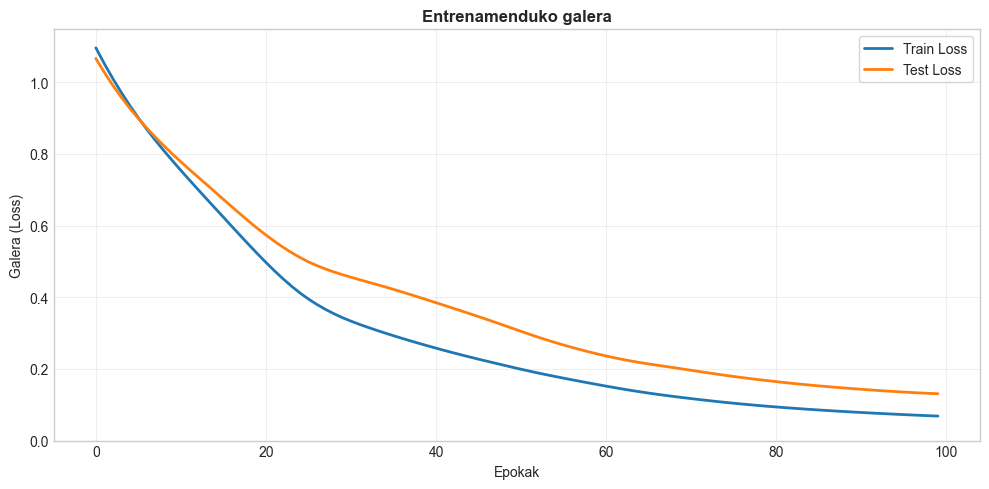

In [10]:
### Suposa dezagun iris aztertu behar dugula
print("Dataseta kargatzen...")

# Iris dataseta kargatu
iris = load_iris()
X = torch.FloatTensor(iris.data)
X = (X - X.mean(dim=0)) / X.std(dim=0)
y = torch.LongTensor(iris.target)

# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Iris dataset:")
print(f"\tTrain: {X_train.shape[0]} instantzia, {X_train.shape[1]} datu (dimentsio)")
print(f"\tTest:  {X_test.shape[0]} instantzia")
print(f"\tKlase izenak: {len(torch.unique(y))}")

## Modeloa entrenatu
# kargatu
modelo = SareNeuronalSinplea(input_size=4, hidden_size=16, output_size=3)
# entrenatu 100 epokatan
train_losses, test_losses = modeloa_entrenatu(
    modelo, X_train, y_train, X_test, y_test,
    epochs=100, learning_rate=0.01
)

# Errore galera grafika
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epokak')
plt.ylabel('Galera (Loss)')
plt.ylim(bottom=0)
plt.title('Entrenamenduko galera', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8️⃣ Modelo ebaluazioa

Entrenamenduaren ondoren, garrantzitsua da ebaluatzea nola egiten duen modeloak datu berrietan.

In [11]:
# Ebaluazio metodoa
def modelo_ebaluatu(modelo, X_test, y_test):
    """Test-en lortutako emaitzak ebaluatu"""

    modelo.eval()

    with torch.no_grad():
        y_pred = modelo(X_test)
        y_pred = torch.softmax(y_pred,dim=1)
        iragarpenak = torch.argmax(y_pred, dim=1)

        # accuracy
        corrects = (iragarpenak == y_test).float()
        accuracy = corrects.mean().item()

        return accuracy, iragarpenak

# ebaluatu
accuracy, iragarpenak = modelo_ebaluatu(modelo, X_test, y_test)

print("=" * 50)
print("MODELO EBALUAZIOA")
print("=" * 50)
print(f"\nTesteko accuracy: {accuracy * 100:.2f}%")
print(f"Ondo egindako guztira: {int(accuracy * len(y_test))}/{len(y_test)}")

# egindako iragarpen batzuen bistarapena
print("\nLehenengo 10 instantzien iragarpenak:")
print(f"{'Iragarpena':>12} {'Egia':>12} {'Zuzena?':>12}")
print("-" * 40)
for i in range(min(10, len(iragarpenak))):
    pred = iragarpenak[i].item()
    true = y_test[i].item()
    zuzen = "✅" if pred == true else "❌"
    print(f"{pred:>12} {true:>12} {zuzen:>12}")

MODELO EBALUAZIOA

Testeko accuracy: 93.33%
Ondo egindako guztira: 42/45

Lehenengo 10 instantzien iragarpenak:
  Iragarpena         Egia      Zuzena?
----------------------------------------
           2            2            ✅
           1            1            ✅
           1            2            ❌
           1            1            ✅
           2            2            ✅
           2            2            ✅
           1            1            ✅
           1            1            ✅
           0            0            ✅
           2            2            ✅


## 9️⃣ Konparazioa: Sare Neuronala vs Ikusitako algoritmoak

Nola konparatzen da sare neuronal bat ezagutzen dituzuen algoritmoekin?

Modeloak entrenatzen...


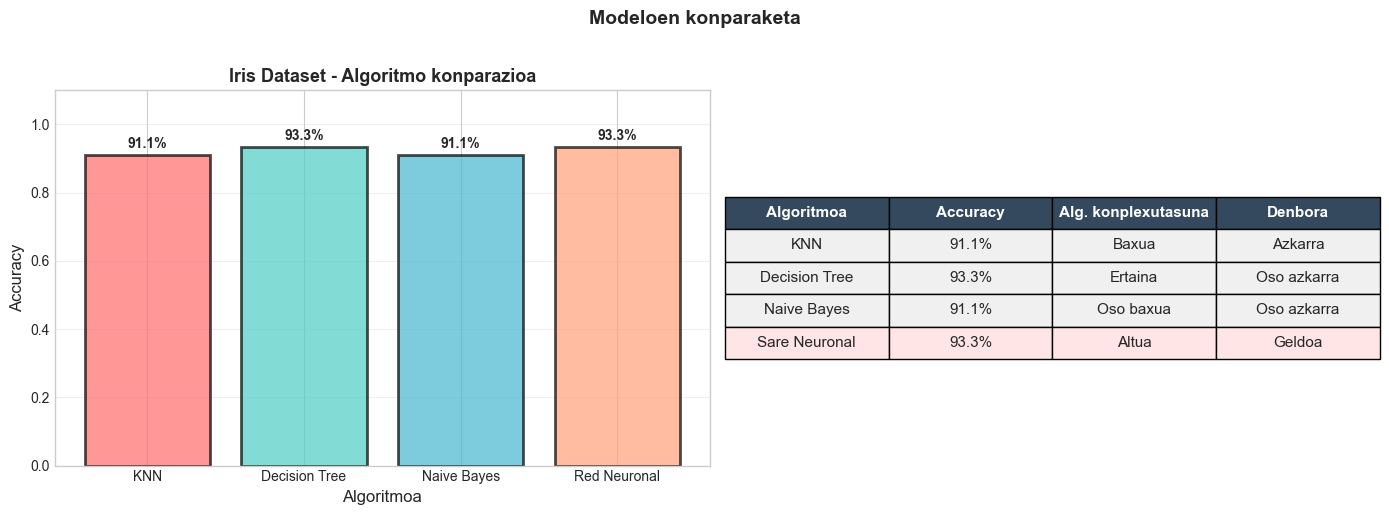

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# numpy-ra bihurtu sklearn erako
X_train_np = X_train.numpy()
y_train_np = y_train.numpy()
X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

# Entrenar modelos
print("Modeloak entrenatzen...")
print("=" * 60)

# KNN
knn = KNeighborsClassifier(n_neighbors=5,)
knn.fit(X_train_np, y_train_np)
knn_acc = knn.score(X_test_np, y_test_np)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_np, y_train_np)
dt_acc = dt.score(X_test_np, y_test_np)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_np, y_train_np)
nb_acc = nb.score(X_test_np, y_test_np)

# Sare Neuronala (jada kalkulatuak)
nn_acc = accuracy

# Acc konparaketa
konparazio_dict = {
    'KNN': knn_acc,
    'Decision Tree': dt_acc,
    'Naive Bayes': nb_acc,
    'Red Neuronal': nn_acc
}

### GRAFIKOAK
#############
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barra grafikoa
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
algoritmoak = list(konparazio_dict.keys())
acc_lista = list(konparazio_dict.values())

ax1.bar(algoritmoak, acc_lista, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Algoritmoa', fontsize=12)
ax1.set_title('Iris Dataset - Algoritmo konparazioa', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3)

# Barra diagrama bete
for i, (alg, prec) in enumerate(konparazio_dict.items()):
    ax1.text(i, prec + 0.02, f'{prec*100:.1f}%', ha='center', fontweight='bold')

# konparazio taula
ax2.axis('off')
taula_data = [
    ['Algoritmoa', 'Accuracy', 'Alg. konplexutasuna', 'Denbora'],
    ['KNN', f'{knn_acc*100:.1f}%', 'Baxua', 'Azkarra'],
    ['Decision Tree', f'{dt_acc*100:.1f}%', 'Ertaina', 'Oso azkarra'],
    ['Naive Bayes', f'{nb_acc*100:.1f}%', 'Oso baxua', 'Oso azkarra'],
    ['Sare Neuronal', f'{nn_acc*100:.1f}%', 'Altua', 'Geldoa']
]

taula = ax2.table(cellText=taula_data, cellLoc='center', loc='center',
                 colWidths=[0.25, 0.25, 0.25, 0.25])
taula.auto_set_font_size(False)
taula.set_fontsize(11)
taula.scale(1, 2)

# izenburua koloreztatu
for i in range(4):
    taula[(0, i)].set_facecolor('#34495e')
    taula[(0, i)].set_text_props(weight='bold', color='white')

# Errenkadak koloreztatu
for i in range(1, 5):
    for j in range(4):
        if i == 4:  # SN
            taula[(i, j)].set_facecolor('#FFE5E5')
        else:
            taula[(i, j)].set_facecolor('#F0F0F0')

plt.suptitle('Modeloen konparaketa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig.savefig(
    fname='irudiak/modelo_konparaketa.pdf',
    format='pdf',
    bbox_inches="tight",
    pad_inches='layout'
)

## 🔟 Laburpena

### PyTorch klase nagusiak:

| Klasea | Erabilera | Adibidea |
|-------|-----|---------|
| `nn.Module` | Modeloak sortzeko oinarrizko klasea | `class SareNeuronalSinplea(nn.Module)` |
| `nn.Linear` | Geruzak sortzeko | `nn.Linear(10, 5)` |
| `nn.ReLU` | Aktibazio funtzioa: ReLU | `nn.ReLU()` |
| `nn.Sigmoid` | Aktibazio funtzioa: Sigmoidea | `nn.Sigmoid()` |
| `nn.CrossEntropyLoss` | Galera kalkulatzeko (multiklasea) | `criterio = nn.CrossEntropyLoss()` |
| `optim.Adam` | Optimizatzailea | `opt = optim.Adam(model.parameters())` |
| `optim.SGD` | Optimizatzailea (Konputazio kostu baxuagoa) | `opt = optim.SGD(model.parameters(), lr=0.01)` |


### Alde onak eta txarrak:

**SN Alde Onak:**
- ✅ Oso patroi konplexuak ikas ditzakete
- ✅ Oso datu handietara eskalatzeko modukoak
- ✅ Malguak: arkitektura posible asko
- ✅ Gauregunekotasunean, laguntza asko.

**SN Alde Txarrak:**
- ❌ Entrenatzeko geldoagoa
- ❌ Datu gehiago behar dira
- ❌ Ez hain interpretagarria ("caja negra")
- ❌ Hiperparametroen tuning handiagoa behar du

## Beste adibide bat: MultiClass sailkapena 3 kapako Sare Neuronal Sakon bat erabiliz

Hemen adibide errealistagoa, sare konplexuagoa duena:

In [13]:
# SN-Sakona
class SNSakona(nn.Module):
    """
    Sare Neuronal Sakona

    Arkitektura:
    Input (4) -> 16 -> 8 -> Output (3)
    """

    def __init__(self, input_size=4, output_size=3):
        super(SNSakona, self).__init__()

        # geruzak definitu
        self.hl1 = nn.Linear(input_size, 16)
        self.hl2 = nn.Linear(16, 8)

        self.irteera = nn.Linear(8, output_size)

        # Overfitting saiesteko dropout erabili
        # iterazio bakoitzan neurona % bat ez da erabiliko, funtzionamendua hobetzeko
        self.dropout = nn.Dropout(0.1) # %40

    def forward(self, x):
        # Lehenengo kapa izkutua
        x = self.hl1(x)
        x = torch.relu(x)
        hasi_kapa = nn.Dropout(p=0.1) # hasierako kapako dropout %25
        x = hasi_kapa(x)

        # Bigarren kapa izkutua
        x = self.hl2(x)
        x = torch.relu(x)
        x = self.dropout(x)

        # Irteera kapa
        x = self.irteera(x)

        return x

SARE NEURONAL SAKONA
SNSakona(
  (hl1): Linear(in_features=4, out_features=16, bias=True)
  (hl2): Linear(in_features=16, out_features=8, bias=True)
  (irteera): Linear(in_features=8, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

Parametro kopurua: 243

SNS ENTRENATZEN...
Entrenamendua hasieratzen...
Epoka  10/100 | Train Loss: 0.7455 | Test Loss: 0.7523
Epoka  20/100 | Train Loss: 0.3820 | Test Loss: 0.4401
Epoka  30/100 | Train Loss: 0.2361 | Test Loss: 0.2932
Epoka  40/100 | Train Loss: 0.1885 | Test Loss: 0.1867
Epoka  50/100 | Train Loss: 0.2027 | Test Loss: 0.1455
Epoka  60/100 | Train Loss: 0.0901 | Test Loss: 0.1549
Epoka  70/100 | Train Loss: 0.1431 | Test Loss: 0.1296
Epoka  80/100 | Train Loss: 0.0597 | Test Loss: 0.1299
Epoka  90/100 | Train Loss: 0.0748 | Test Loss: 0.1293
Epoka 100/100 | Train Loss: 0.0621 | Test Loss: 0.0791
Entrenamendua bukatuta!

SN Sakona accuracy: %93.33
SN accuracy:   %93.33


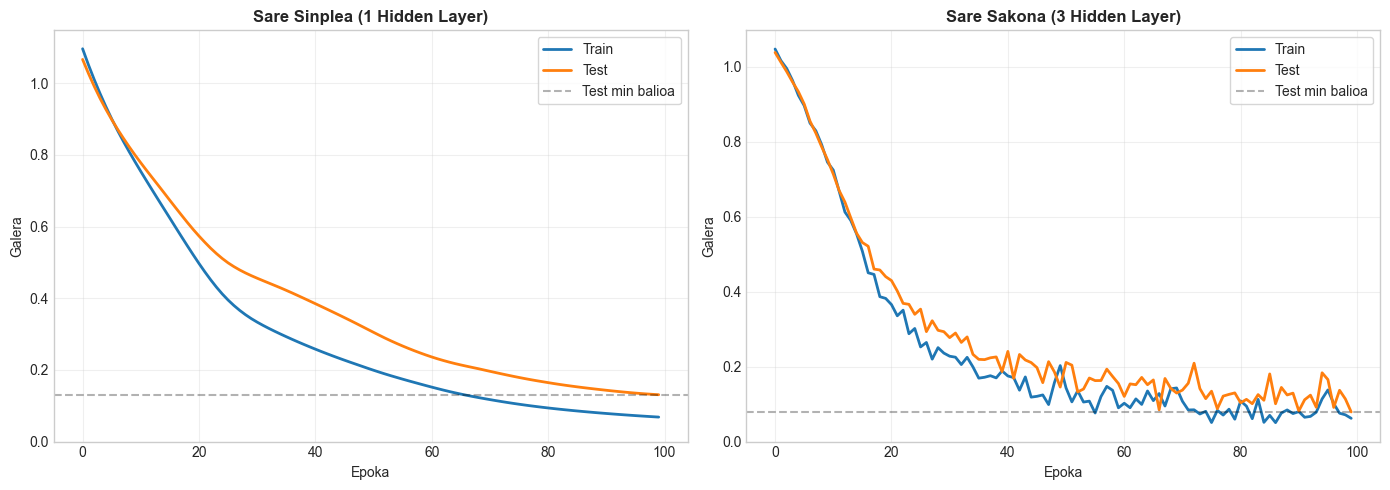

In [14]:
# Sortu eta arkitektura inprimatu
modelo_sakona = SNSakona()
print("=" * 60)
print("SARE NEURONAL SAKONA")
print("=" * 60)
print(modelo_sakona)
print("\nParametro kopurua:", sum(p.numel() for p in modelo_sakona.parameters()))

# Entrenamendua
print("\n" + "=" * 60)
print("SNS ENTRENATZEN...")
print("=" * 60)

train_losses_prof, test_losses_prof = modeloa_entrenatu(
    modelo_sakona, X_train, y_train, X_test, y_test,
    epochs=100, learning_rate=0.01
)

# Ebaluazioa
accuracy_prof, pred_prof = modelo_ebaluatu(modelo_sakona, X_test, y_test)
print(f"\nSN Sakona accuracy: %{accuracy_prof * 100:.2f}")
print(f"SN accuracy:   %{accuracy * 100:.2f}")

# Bi modeloen alderaketa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sare Sinplea
axes[0].plot(train_losses, label='Train', linewidth=2)
axes[0].plot(test_losses, label='Test', linewidth=2)
axes[0].axhline(np.min(test_losses), alpha=0.3, c='black', linestyle='--', label='Test min balioa')
axes[0].set_title('Sare Sinplea (1 Hidden Layer)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Galera')
axes[0].set_ylim(bottom=0)
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Sare Sakona
axes[1].plot(train_losses_prof, label='Train', linewidth=2)
axes[1].plot(test_losses_prof, label='Test', linewidth=2)
axes[1].axhline(np.min(test_losses_prof), alpha=0.3, c='black', linestyle='--', label='Test min balioa')
axes[1].set_title('Sare Sakona (3 Hidden Layer)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Galera')
axes[1].set_ylim(bottom=0)
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig(
    fname='irudiak/sn_konparazioa.pdf',
    format='pdf',
    bbox_inches="tight",
    pad_inches='layout'
)